# Classical Feature Ensemble (All Families)

This notebook uses **one unified table**:
`extracted_features/combined/all_families_features.csv`

Pipeline:
1. Load the combined feature matrix.
2. Train multiple classical models.
3. Compare validation performance.
4. Refit models on full train split.
5. Build a weighted late-fusion ensemble across models.
6. Evaluate on held-out test and save artifacts.


## 1) Imports


In [8]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC

plt.style.use('ggplot')
np.random.seed(42)
print('Imports loaded.')


Imports loaded.


## 2) Configuration


In [9]:
RANDOM_STATE = 42
TEST_SIZE = 0.20
VAL_SIZE = 0.20

TARGET_COL = 'emotion'
ID_COL = 'path'

COMBINED_CSV_REL = 'extracted_features/combined/all_families_features.csv'
OUT_DIR_REL = 'feature_test/classical_feature_system/artifacts_all_families'

# Classical models evaluated on the same all-features matrix
MODEL_NAMES = [
    'logreg',
    'svm_rbf',
    'random_forest',
    'hist_gb',
    'mlp',
]

METADATA_COLS = {
    'path', 'session', 'method', 'gender', 'emotion',
    'n_annotators', 'agreement', 'utt_id', 'text', 'split'
}

print('Config ready.')


Config ready.


## 3) Paths and Helpers


In [10]:
def resolve_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / 'pyproject.toml').exists():
        return cwd
    for parent in cwd.parents:
        if (parent / 'pyproject.toml').exists():
            return parent
    raise FileNotFoundError('Could not find project root with pyproject.toml')


def build_model_zoo(random_state: int) -> dict[str, Any]:
    return {
        'logreg': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=random_state)),
        ]),
        'svm_rbf': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', SVC(kernel='rbf', C=3.0, gamma='scale', class_weight='balanced', probability=True, random_state=random_state)),
        ]),
        'random_forest': RandomForestClassifier(
            n_estimators=400,
            class_weight='balanced_subsample',
            random_state=random_state,
            n_jobs=-1,
        ),
        'hist_gb': HistGradientBoostingClassifier(
            random_state=random_state,
            max_iter=300,
            learning_rate=0.08,
        ),
        'mlp': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', MLPClassifier(
                hidden_layer_sizes=(256, 128),
                activation='relu',
                alpha=1e-4,
                max_iter=250,
                early_stopping=True,
                random_state=random_state,
            )),
        ]),
    }


def evaluate(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    return {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'f1_macro': float(f1_score(y_true, y_pred, average='macro')),
        'f1_weighted': float(f1_score(y_true, y_pred, average='weighted')),
    }


REPO_ROOT = resolve_repo_root()
COMBINED_CSV = (REPO_ROOT / COMBINED_CSV_REL).resolve()
OUT_DIR = (REPO_ROOT / OUT_DIR_REL).resolve()
OUT_DIR.mkdir(parents=True, exist_ok=True)

print('REPO_ROOT:', REPO_ROOT)
print('COMBINED_CSV:', COMBINED_CSV)
print('OUT_DIR:', OUT_DIR)


REPO_ROOT: F:\Speech-Emotion-Recognition
COMBINED_CSV: F:\Speech-Emotion-Recognition\extracted_features\combined\all_families_features.csv
OUT_DIR: F:\Speech-Emotion-Recognition\feature_test\classical_feature_system\artifacts_all_families


## 4) Load Combined All-Families Features


In [11]:
if not COMBINED_CSV.exists():
    raise FileNotFoundError(f'Missing combined CSV: {COMBINED_CSV}')

df = pd.read_csv(COMBINED_CSV)

if ID_COL not in df.columns or TARGET_COL not in df.columns:
    raise ValueError(f'Required columns missing. Need {ID_COL} and {TARGET_COL}.')

# Strict column handling: explicitly remove known metadata/non-feature text columns.
known_drop_cols = {
    'path', 'session', 'method', 'gender', 'emotion',
    'n_annotators', 'agreement', 'utt_id', 'text', 'split',
    'tfidf__utt_id', 'tfidf__text', 'tfidf__split',
    'bert__utt_id', 'bert__text', 'bert__split',
}

feature_cols = [c for c in df.columns if c not in known_drop_cols]
if not feature_cols:
    raise ValueError('No feature columns found after removing known non-feature columns.')

# Fail fast if unexpected non-numeric columns remain.
unexpected_non_numeric = [
    c for c in feature_cols if not pd.api.types.is_numeric_dtype(df[c])
]
if unexpected_non_numeric:
    sample = unexpected_non_numeric[:20]
    raise ValueError(
        'Unexpected non-numeric feature columns found. '
        f'Count={len(unexpected_non_numeric)} Sample={sample}'
    )

work_df = df[[ID_COL, TARGET_COL] + feature_cols].dropna(subset=[ID_COL, TARGET_COL]).copy()
work_df = work_df.drop_duplicates(subset=[ID_COL], keep='first')

# Combined feature tables can have sparse/missing values across families.
missing_before_fill = int(work_df[feature_cols].isna().sum().sum())
work_df[feature_cols] = work_df[feature_cols].fillna(0.0)

print(f'Rows after cleaning: {len(work_df)}')
print(f'Total numeric feature columns: {len(feature_cols)}')
print(f'Feature NaNs filled with 0.0: {missing_before_fill}')
print('Sample feature columns:', feature_cols[:12])



Rows after cleaning: 7532
Total numeric feature columns: 14021
Feature NaNs filled with 0.0: 46852
Sample feature columns: ['mfcc_raw__duration_s', 'mfcc_raw__mfcc13_mfcc_frames', 'mfcc_raw__mfcc13_mfcc_mean', 'mfcc_raw__mfcc13_mfcc_std', 'mfcc_raw__mfcc13_mfcc_min', 'mfcc_raw__mfcc13_mfcc_max', 'mfcc_raw__mfcc13_mfcc_median', 'mfcc_raw__mfcc13_mfcc_c00_mean', 'mfcc_raw__mfcc13_mfcc_c00_std', 'mfcc_raw__mfcc13_mfcc_c00_min', 'mfcc_raw__mfcc13_mfcc_c00_max', 'mfcc_raw__mfcc13_mfcc_c00_median']


## 4b) Utterance Row-Consistency Checks

Validate that each row is a single utterance and that optional per-family `__utt_id` fields are consistent with each other and with `path` stem.


In [12]:
# 1) Ensure one row per utterance key (path)
dup_paths = int(work_df[ID_COL].duplicated().sum())
print('Duplicate path rows:', dup_paths)
if dup_paths > 0:
    raise ValueError(f'Found {dup_paths} duplicate paths; expected one row per utterance.')

# 2) Compare all available __utt_id columns
utt_cols = [c for c in df.columns if c.endswith('__utt_id')]
print('Found utt_id columns:', utt_cols)

if utt_cols:
    utt_df = df[[ID_COL] + utt_cols].dropna(subset=[ID_COL]).copy()

    # Convert path -> stem for comparison (utterance-like key)
    path_stem = utt_df[ID_COL].astype(str).map(lambda s: Path(s).stem)

    # Pairwise mismatch counts between utt_id columns
    pairwise_mismatch = []
    for i in range(len(utt_cols)):
        for j in range(i + 1, len(utt_cols)):
            a, b = utt_cols[i], utt_cols[j]
            valid = utt_df[a].notna() & utt_df[b].notna()
            mism = int((utt_df.loc[valid, a].astype(str) != utt_df.loc[valid, b].astype(str)).sum())
            pairwise_mismatch.append({'col_a': a, 'col_b': b, 'n_mismatch': mism, 'n_compared': int(valid.sum())})

    pairwise_df = pd.DataFrame(pairwise_mismatch)
    if not pairwise_df.empty:
        display(pairwise_df)

    # Mismatch vs path stem
    path_mismatch = {}
    for c in utt_cols:
        valid = utt_df[c].notna()
        mism = int((utt_df.loc[valid, c].astype(str) != path_stem.loc[valid]).sum())
        path_mismatch[c] = {'n_mismatch_vs_path_stem': mism, 'n_compared': int(valid.sum())}

    path_mismatch_df = pd.DataFrame(path_mismatch).T.reset_index().rename(columns={'index': 'utt_col'})
    display(path_mismatch_df)

    total_pairwise_mismatch = int(pairwise_df['n_mismatch'].sum()) if not pairwise_df.empty else 0
    total_path_mismatch = int(path_mismatch_df['n_mismatch_vs_path_stem'].sum()) if not path_mismatch_df.empty else 0

    if total_pairwise_mismatch == 0 and total_path_mismatch == 0:
        print('Utterance consistency check: PASS')
    else:
        print('Utterance consistency check: WARN (inspect mismatch tables above)')
else:
    print('No __utt_id columns found; path uniqueness check only.')



Duplicate path rows: 0
Found utt_id columns: ['tfidf__utt_id', 'bert__utt_id']


,col_a,col_b,n_mismatch,n_compared
0,tfidf__utt_id,bert__utt_id,0,7532


,utt_col,n_mismatch_vs_path_stem,n_compared
0,tfidf__utt_id,0,7532
1,bert__utt_id,0,7532


Utterance consistency check: PASS


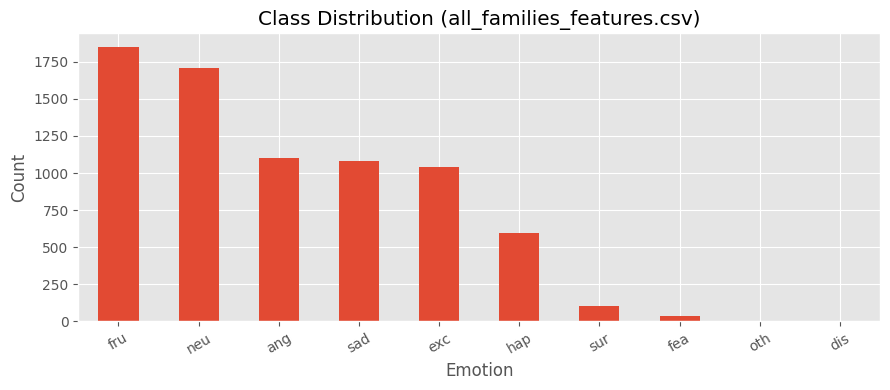

In [13]:
# Visualization: class distribution
class_counts = work_df[TARGET_COL].astype(str).value_counts()
fig, ax = plt.subplots(figsize=(9, 4))
class_counts.plot(kind='bar', ax=ax)
ax.set_title('Class Distribution (all_families_features.csv)')
ax.set_xlabel('Emotion')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


,family,n_features
4,tfidf,9155
8,ssl_embeddings,1539
1,mfcc_normalized,1150
0,mfcc_raw,1150
5,bert,768
6,representations,136
9,tonality,91
3,prosody_pitch,14
7,rhythm_pauses,10
2,prosody_energy,8


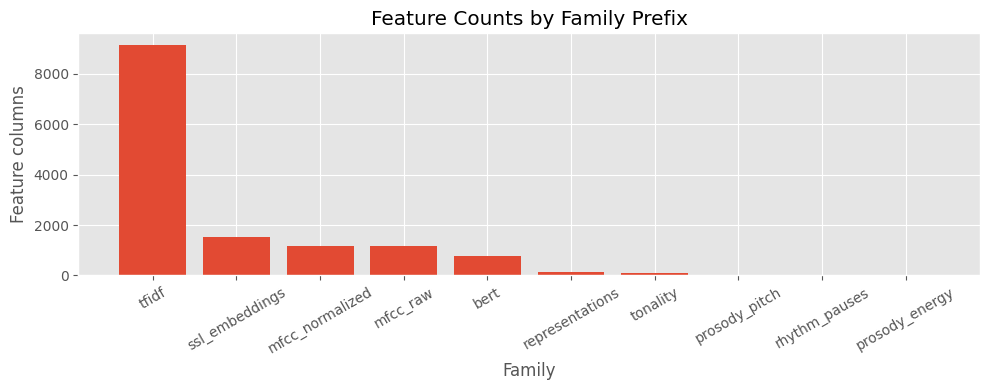

In [14]:
# Visualization: approximate feature-family contribution by prefix before '__'
family_counts = {}
for col in feature_cols:
    family = col.split('__', 1)[0] if '__' in col else 'unscoped'
    family_counts[family] = family_counts.get(family, 0) + 1

family_df = pd.DataFrame({'family': list(family_counts.keys()), 'n_features': list(family_counts.values())})
family_df = family_df.sort_values('n_features', ascending=False)
display(family_df)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(family_df['family'], family_df['n_features'])
ax.set_title('Feature Counts by Family Prefix')
ax.set_xlabel('Family')
ax.set_ylabel('Feature columns')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


## 5) Global Train / Validation / Test Split


In [15]:
X = work_df[feature_cols].to_numpy(dtype=np.float64, copy=False)
label_enc = LabelEncoder()
y = label_enc.fit_transform(work_df[TARGET_COL].astype(str).to_numpy())

idx = np.arange(len(work_df))
idx_train, idx_test = train_test_split(
    idx,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

y_train = y[idx_train]
y_test = y[idx_test]

idx_tr, idx_val = train_test_split(
    idx_train,
    test_size=VAL_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_train,
)

y_tr = y[idx_tr]
y_val = y[idx_val]

X_tr, X_val = X[idx_tr], X[idx_val]
X_train, X_test = X[idx_train], X[idx_test]

print('Train rows:', len(idx_train))
print('Val rows:', len(idx_val))
print('Test rows:', len(idx_test))
print('Classes:', list(label_enc.classes_))


Train rows: 6025
Val rows: 1205
Test rows: 1507
Classes: ['ang', 'dis', 'exc', 'fea', 'fru', 'hap', 'neu', 'oth', 'sad', 'sur']


## 6) Train Classical Models and Compare on Validation


In [ ]:
model_zoo = build_model_zoo(RANDOM_STATE)
unknown = [m for m in MODEL_NAMES if m not in model_zoo]
if unknown:
    raise ValueError(f'Unknown model names: {unknown}')

rows = []
val_pred_by_model = {}

top_val_f1 = -1.0
best_model_name = None

for model_name in MODEL_NAMES:
    model = model_zoo[model_name]
    model.fit(X_tr, y_tr)

    pred_val = model.predict(X_val)
    val_pred_by_model[model_name] = pred_val
    metrics_val = evaluate(y_val, pred_val)

    rows.append({
        'model': model_name,
        'split': 'val',
        **metrics_val,
    })

    print(f'{model_name:<14} val_f1_macro={metrics_val["f1_macro"]:.4f} val_acc={metrics_val["accuracy"]:.4f}')

    if metrics_val['f1_macro'] > top_val_f1:
        top_val_f1 = metrics_val['f1_macro']
        best_model_name = model_name

print(f'\nBest validation model: {best_model_name} (macro-F1={top_val_f1:.4f})')


logreg         val_f1_macro=0.4304 val_acc=0.5934


In [ ]:
val_df = pd.DataFrame(rows)
display(val_df)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(val_df['model'], val_df['f1_macro'])
ax.set_title('Validation Macro-F1 by Model (All Families)')
ax.set_xlabel('Model')
ax.set_ylabel('Macro-F1')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()


## 7) Refit on Full Train and Evaluate on Test


In [ ]:
# Refit each model on full train split and evaluate on test.
test_pred_by_model = {}
test_proba_by_model = {}

for model_name in MODEL_NAMES:
    model = model_zoo[model_name]
    model.fit(X_train, y_train)

    pred_test = model.predict(X_test)
    proba_test = model.predict_proba(X_test)

    test_pred_by_model[model_name] = pred_test
    test_proba_by_model[model_name] = proba_test

    metrics_test = evaluate(y_test, pred_test)
    rows.append({
        'model': model_name,
        'split': 'test',
        **metrics_test,
    })

    print(f'{model_name:<14} test_f1_macro={metrics_test["f1_macro"]:.4f} test_acc={metrics_test["accuracy"]:.4f}')

metrics_df = pd.DataFrame(rows)
display(metrics_df)


## 8) Ensemble Module (Model-Level Weighted Late Fusion)

Weights are proportional to each model's validation macro-F1.


In [ ]:
val_lookup = metrics_df[metrics_df['split'] == 'val'].set_index('model')['f1_macro'].to_dict()
weights = np.array([max(val_lookup[m], 1e-8) for m in MODEL_NAMES], dtype=float)
weights = weights / weights.sum()

fused_proba = np.zeros_like(next(iter(test_proba_by_model.values())))
for w, m in zip(weights, MODEL_NAMES, strict=True):
    fused_proba += w * test_proba_by_model[m]

pred_fused = np.argmax(fused_proba, axis=1)
metrics_fused = evaluate(y_test, pred_fused)

rows.append({
    'model': 'late_fusion_weighted',
    'split': 'test_fusion',
    **metrics_fused,
})
metrics_df = pd.DataFrame(rows)

print('Fusion weights:')
for m, w in zip(MODEL_NAMES, weights, strict=True):
    print(f'  {m:<14} {w:.3f}')

print('\nLate-fusion test metrics:')
print(metrics_fused)

print('\nClassification report (late fusion):')
print(classification_report(y_test, pred_fused, target_names=label_enc.classes_, zero_division=0))


In [ ]:
# Visualization: fusion weights
w_df = pd.DataFrame({'model': MODEL_NAMES, 'weight': weights}).sort_values('weight', ascending=False)
display(w_df)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(w_df['model'], w_df['weight'])
ax.set_title('Late-Fusion Weights by Model')
ax.set_xlabel('Model')
ax.set_ylabel('Weight')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()


In [ ]:
# Visualization: confusion matrix (late fusion)
cm = confusion_matrix(y_test, pred_fused)
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_enc.classes_).plot(
    cmap='Blues',
    values_format='d',
    xticks_rotation=45,
    ax=ax,
)
ax.set_title('Late-Fusion Confusion Matrix (Test)')
plt.tight_layout()
plt.show()


## 9) Save Artifacts


In [ ]:
metrics_df.to_csv(OUT_DIR / 'metrics_table.csv', index=False)

test_ref = work_df.iloc[idx_test].reset_index(drop=True)
pred_out = pd.DataFrame({
    ID_COL: test_ref[ID_COL].astype(str),
    'emotion_true': label_enc.inverse_transform(y_test),
    'emotion_pred_late_fusion': label_enc.inverse_transform(pred_fused),
})
for m in MODEL_NAMES:
    pred_out[f'emotion_pred_{m}'] = label_enc.inverse_transform(test_pred_by_model[m])
pred_out.to_csv(OUT_DIR / 'test_predictions.csv', index=False)

summary = {
    'data_source': str(COMBINED_CSV),
    'rows_after_cleaning': int(len(work_df)),
    'feature_count': int(len(feature_cols)),
    'models_considered': MODEL_NAMES,
    'train_rows': int(len(idx_train)),
    'val_rows': int(len(idx_val)),
    'test_rows': int(len(idx_test)),
    'classes': [str(c) for c in label_enc.classes_],
    'fusion_weights': {m: float(w) for m, w in zip(MODEL_NAMES, weights, strict=True)},
    'late_fusion_test_metrics': metrics_fused,
}
with (OUT_DIR / 'summary.json').open('w', encoding='utf-8') as handle:
    json.dump(summary, handle, indent=2)

print('Saved artifacts in:', OUT_DIR)
print('-', OUT_DIR / 'metrics_table.csv')
print('-', OUT_DIR / 'test_predictions.csv')
print('-', OUT_DIR / 'summary.json')


## 10) Final Comparison Table


In [ ]:
view_df = metrics_df[metrics_df['split'].isin(['test', 'test_fusion'])].copy()
view_df = view_df.sort_values('f1_macro', ascending=False)
display(view_df[['model', 'split', 'accuracy', 'f1_macro', 'f1_weighted']])
